# Analiza jakości danych w systemie

## 1. Wprowadzenie

### 1.1 Cel analizy

Celem niniejszej analizy jest ocena jakości danych zgromadzonych w hurtowni oraz identyfikacja potencjalnych problemów mogących wpłynąć na wiarygodność prowadzonych analiz.

### 1.2 Zakres analizy

Analiza obejmuje dane z sezonów 2007/2008 - 2025/2026, z 50 lig piłkarskich z 25 krajów. Sezon 2025/2026 jest traktowany jako sezon bieżący i nie jest uwzględniany w analizach kompletności.

### 1.3 Metodologia

Przedstawione analizy opierają się na danych pobranych ze znormalizowanej części hurtowni. Do weryfikacji jakości wykorzystano zestaw metryk obejmujących kompletność, spójność oraz poprawność danych.

In [ ]:
from sqlalchemy import create_engine
import urllib
from sqlalchemy import inspect
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
sns.set_palette("deep")

In [ ]:
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost,1433;"
    "DATABASE=LEAGUE_DB;"
    "UID=sa;"
    "PWD=YourStrongPassword1!;"
    "TrustServerCertificate=yes;"
)

source_engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    fast_executemany=True
)

_source_inspector = inspect(source_engine)

In [22]:
destination_engine = create_engine(f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:" \
    f"{os.environ['POSTGRES_PASSWORD']}@localhost:{os.environ['POSTGRES_PORT']}" \
    f"/{os.environ['POSTGRES_DB']}"
)

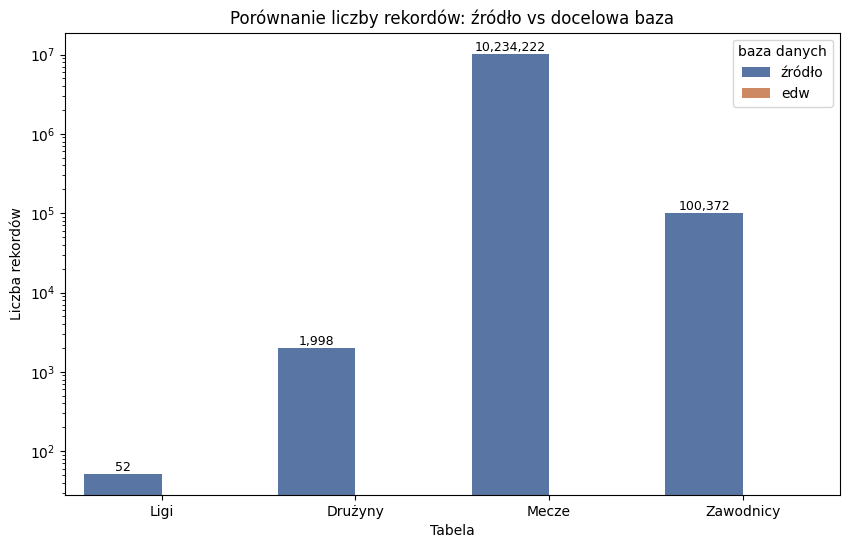

In [ ]:
sl_query = 'SELECT COUNT(*) FROM dbo.T_DIM_LEAGUE;'
sl_df = pd.read_sql(sl_query, source_engine)
sl_count = sl_df.iloc[0, 0]

dl_query = 'SELECT COUNT(*) FROM core.leagues;'
dl_df = pd.read_sql(dl_query, destination_engine)
dl_count = dl_df.iloc[0, 0]

sm_query = 'SELECT COUNT(*) FROM dbo.T_F_Match_Stats;'
sm_df = pd.read_sql(sm_query, source_engine)
sm_count = sm_df.iloc[0, 0]

dm_query = 'SELECT COUNT(*) FROM core.matches;'
dm_df = pd.read_sql(dm_query, destination_engine)
dm_count = dm_df.iloc[0, 0]

st_query = 'SELECT COUNT(*) FROM dbo.T_DIM_TEAM;'
st_df = pd.read_sql(st_query, source_engine)
st_count = st_df.iloc[0, 0]

dt_query = 'SELECT COUNT(*) FROM core.matches;'
dt_df = pd.read_sql(dt_query, destination_engine)
dt_count = dt_df.iloc[0, 0]

sp_query = 'SELECT COUNT(*) FROM dbo.T_DIM_PLAYER;'
sp_df = pd.read_sql(sp_query, source_engine)
sp_count = sp_df.iloc[0, 0]

dp_query = 'SELECT COUNT(*) FROM core.players;'
dp_df = pd.read_sql(dp_query, destination_engine)
dp_count = dp_df.iloc[0, 0]

plot_df = pd.DataFrame([
    { 
        "tabela": "Ligi",
        "źródło": sl_count,
        "edw": dl_count
    },
    { 
        "tabela": "Drużyny",
        "źródło": st_count,
        "edw": dt_count
    },
    { 
        "tabela": "Mecze",
        "źródło": sm_count,
        "edw": dm_count
    },
    { 
        "tabela": "Zawodnicy",
        "źródło": sp_count,
        "edw": dp_count
    }
])

plot_long = plot_df.melt(id_vars="tabela", value_vars=["źródło", "edw"], 
                         var_name="baza danych", value_name="liczba_rekordów")

plt.figure(figsize=(10,6))
ax = sns.barplot(data=plot_long, x="tabela", y="liczba_rekordów", hue="baza danych")
plt.yscale("log")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, rotation=0)

plt.title("Porównanie liczby rekordów: źródło vs docelowa baza")
plt.ylabel("Liczba rekordów")
plt.xlabel("Tabela")
plt.show()
